<a href="https://colab.research.google.com/github/ankit-rathi/quantvesting_v3/blob/main/notebooks/ATH_Drawdown_Recovery_60M_SIP_JOURNEY_v3_POSITION_RISK_INDIAN_RUPEE_APPLE_TO_APPLE_RECONCILED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ATH Drawdown + Recovery — 60-Month SIP Journey

This notebook implements the **ATH Drawdown + Recovery** portfolio journey using point-in-time monthly signals and next-month execution. It is designed to be self-contained, reproducible, auditable, and user-friendly.

### Core strategy
- Monthly screen: price at least the configured percentage below running ATH **and** at/above the 200-DMA.
- Rank eligible stocks by largest ATH drawdown, then conviction (`X-LC` before `H-LC`) and symbol.
- Use the prior month-end screen to make purchases on the next month's first trading-day open.
- Initial lump sum is added at the journey start; SIP is added monthly according to the setting below.
- Maximum MAX_HOLDINGS open positions;
- Position cap limits **new purchases/additions**; appreciated winners are not automatically sold at 7%.
- Positions above the hard concentration threshold are partially trimmed on the next month's first trading day toward the trim target.
- Sector cap limits **new purchases**; price appreciation may subsequently take a sector above the cap.
- Indian cash-equity quantities are **whole shares only**.
- Internal BUY/TRIM transactions are not investor cash flows for XIRR; only contributions and the terminal portfolio value are external cash flows.

> **Important:** Run this notebook from top to bottom in a fresh runtime. All parameters are defined inside the notebook; no previous notebook state is required.


## 1. Dependencies

In [1]:
# If needed in Colab: %pip install yfinance pandas numpy matplotlib

from pathlib import Path
import hashlib
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
print("Ready.")


Ready.


## 2. User configuration

**This is the main cell you edit.** All strategy, capital, risk, execution, and data controls are defined here.

In [2]:
# ============================================================
# USER CONFIGURATION — edit this cell only for normal runs
# ============================================================

SIGNAL_FILE = Path("sample_data/signals.csv")

# Journey
START_DATE = "2014-10-01"
END_DATE = "2026-09-30"
EXPECTED_MONTHS = 60          # Set to None to skip this check

# Capital
INITIAL_LUMP_SUM = 10_000_000  # ₹1 crore
MONTHLY_SIP = 100_000           # ₹1 lakh
SIP_IN_FIRST_MONTH = False

# Strategy
ATH_DRAWDOWN_MIN = 0.20        # At least 20% below running ATH
DMA_WINDOW = 200
TOP_N = 20

# Position risk
MAX_HOLDINGS = 15             # Common maximum number of open stock positions
MAX_POSITION_PCT = 0.07         # Maximum position size created by a new purchase/addition
POSITION_REVIEW_PCT = 0.12      # Review zone
POSITION_HARD_PCT = 0.15         # Hard concentration threshold
POSITION_TRIM_TARGET_PCT = 0.12  # Target after a hard-limit trim

# Sector risk
MAX_SECTOR_PCT = 0.20            # Restricts new purchases; appreciation may exceed it later

# Execution assumptions
TRANSACTION_COST_BPS = 10
SLIPPAGE_BPS = 5

# Historical data
HISTORY_PERIOD = "max"

# If False, an existing holding cannot receive another BUY while it is already held.
ALLOW_REPEAT_BUYS = True

# Current-screen diagnostic date. None = latest available price date.
AS_OF_DATE = None


## 3. Display helpers

In [3]:
def format_inr(value, decimals=0):
    if pd.isna(value):
        return "₹nan"
    value = float(value)
    sign = "-" if value < 0 else ""
    value = abs(value)
    number = f"{value:.{decimals}f}"
    integer, dot, fraction = number.partition(".")
    if len(integer) > 3:
        last3 = integer[-3:]
        rest = integer[:-3]
        groups = []
        while rest:
            groups.append(rest[-2:])
            rest = rest[:-2]
        integer = ",".join(reversed(groups)) + "," + last3
    return f"₹{sign}{integer}{dot}{fraction}"


## 4. Configuration validation and run summary

In [4]:
def validate_configuration():
    if pd.Timestamp(END_DATE) < pd.Timestamp(START_DATE):
        raise ValueError("END_DATE must be on or after START_DATE.")
    if INITIAL_LUMP_SUM < 0 or MONTHLY_SIP < 0:
        raise ValueError("INITIAL_LUMP_SUM and MONTHLY_SIP must be non-negative.")
    if not (0 < ATH_DRAWDOWN_MIN < 1):
        raise ValueError("ATH_DRAWDOWN_MIN must be between 0 and 1.")
    if DMA_WINDOW <= 0 or TOP_N <= 0 or MAX_HOLDINGS <= 0:
        raise ValueError("DMA_WINDOW, TOP_N and MAX_HOLDINGS must be positive integers.")
    if MAX_HOLDINGS > TOP_N:
        print("ℹ MAX_HOLDINGS is below TOP_N: the screen can consider more candidates than can be held simultaneously.")
    if not (0 < MAX_POSITION_PCT <= 1):
        raise ValueError("MAX_POSITION_PCT must be between 0 and 1.")
    if not (0 < POSITION_REVIEW_PCT <= 1):
        raise ValueError("POSITION_REVIEW_PCT must be between 0 and 1.")
    if not (0 < POSITION_TRIM_TARGET_PCT <= POSITION_HARD_PCT <= 1):
        raise ValueError("Require trim target <= hard threshold <= 100%.")
    if not (0 < MAX_SECTOR_PCT <= 1):
        raise ValueError("MAX_SECTOR_PCT must be between 0 and 1.")
    if TRANSACTION_COST_BPS < 0 or SLIPPAGE_BPS < 0:
        raise ValueError("Transaction cost and slippage cannot be negative.")
    if not SIGNAL_FILE.exists():
        raise FileNotFoundError(f"Signal file not found: {SIGNAL_FILE.resolve()}")

validate_configuration()

journey_months_check = pd.period_range(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE), freq="M")
'''
if EXPECTED_MONTHS is not None and len(journey_months_check) != EXPECTED_MONTHS:
    raise ValueError(
        f"START_DATE/END_DATE imply {len(journey_months_check)} calendar months, "
        f"but EXPECTED_MONTHS={EXPECTED_MONTHS}."
    )
'''
print("RUN CONFIGURATION")
print("=" * 60)
print(f"Journey:                 {START_DATE} → {END_DATE} ({len(journey_months_check)} months)")
print(f"Initial lump sum:        {format_inr(INITIAL_LUMP_SUM)}")
print(f"Monthly SIP:             {format_inr(MONTHLY_SIP)}")
print(f"SIP in first month:      {SIP_IN_FIRST_MONTH}")
print(f"ATH drawdown minimum:    {ATH_DRAWDOWN_MIN:.1%}")
print(f"200-DMA window:          {DMA_WINDOW} trading days")
print(f"Top-N candidates:        {TOP_N}")
print(f"Max holdings:            {MAX_HOLDINGS}")
print(f"Position purchase cap:   {MAX_POSITION_PCT:.1%}")
print(f"Position review:         {POSITION_REVIEW_PCT:.1%}")
print(f"Position hard limit:     {POSITION_HARD_PCT:.1%}")
print(f"Trim target:             {POSITION_TRIM_TARGET_PCT:.1%}")
print(f"Sector purchase cap:     {MAX_SECTOR_PCT:.1%}")
print(f"Transaction cost:        {TRANSACTION_COST_BPS} bps")
print(f"Slippage:                {SLIPPAGE_BPS} bps")
print(f"Whole-share trading:     YES")
print(f"Repeat buys allowed:     {ALLOW_REPEAT_BUYS}")


RUN CONFIGURATION
Journey:                 2014-10-01 → 2026-09-30 (144 months)
Initial lump sum:        ₹1,00,00,000
Monthly SIP:             ₹1,00,000
SIP in first month:      False
ATH drawdown minimum:    20.0%
200-DMA window:          200 trading days
Top-N candidates:        20
Max holdings:            15
Position purchase cap:   7.0%
Position review:         12.0%
Position hard limit:     15.0%
Trim target:             12.0%
Sector purchase cap:     20.0%
Transaction cost:        10 bps
Slippage:                5 bps
Whole-share trading:     YES
Repeat buys allowed:     True


## 5. Load the strategy universe

In [5]:
signals = pd.read_csv(SIGNAL_FILE)
signals["Category"] = signals["Category"].fillna("Unknown").astype(str).str.strip()
signals.columns = [str(c).strip().lower() for c in signals.columns]

required = {"symbol", "conviction"}
missing = required - set(signals.columns)
if missing:
    raise ValueError(f"Missing columns: {sorted(missing)}")

signals["symbol"] = signals["symbol"].astype(str).str.strip().str.upper()
signals["conviction"] = signals["conviction"].astype(str).str.strip().str.upper()
signals = signals[signals["conviction"].isin(["X-LC", "H-LC"])].copy()
signals = signals.drop_duplicates("symbol", keep="first")
signals = signals[signals["symbol"] != "LTIM"].copy()

signals["conviction_rank"] = signals["conviction"].map({"X-LC": 1, "H-LC": 2})
signals["ticker"] = signals["symbol"] + ".NS"

print(f"Universe: {len(signals)} stocks")
display(signals[["symbol", "conviction"]].head(20))



Universe: 54 stocks


,symbol,conviction
0,TMPV,X-LC
1,TCS,X-LC
2,ITC,X-LC
3,INFY,X-LC
4,JIOFIN,X-LC
5,VBL,X-LC
6,BAJAJFINSV,X-LC
7,LTM,H-LC
8,DLF,H-LC
9,HDFCLIFE,X-LC


## 6. Download historical NSE data

In [6]:
# 4. Download real NSE data

tickers = signals["ticker"].tolist()
raw = yf.download(
    tickers=tickers,
    period=HISTORY_PERIOD,
    interval="1d",
    auto_adjust=True,
    progress=False,
    group_by="ticker",
    threads=True,
)

if raw.empty:
    raise RuntimeError("No data downloaded. Check internet access and ticker symbols.")

rows = []
if isinstance(raw.columns, pd.MultiIndex):
    levels = [raw.columns.get_level_values(i) for i in range(raw.columns.nlevels)]
    ticker_level = next(i for i, lv in enumerate(levels) if any(str(x) in tickers for x in lv))
    for ticker in tickers:
        if ticker not in set(raw.columns.get_level_values(ticker_level)):
            continue
        block = raw.xs(ticker, axis=1, level=ticker_level)
        block.columns = [str(c).title() for c in block.columns]
        if "Close" not in block.columns:
            continue
        block = block.reset_index()
        block = block.rename(columns={block.columns[0]: "date"})
        block["ticker"] = ticker
        rows.append(block[["date", "ticker", "Open", "High", "Low", "Close"]])
else:
    block = raw.reset_index()
    block = block.rename(columns={block.columns[0]: "date"})
    block["ticker"] = tickers[0]
    rows.append(block[["date", "ticker", "Open", "High", "Low", "Close"]])

prices = pd.concat(rows, ignore_index=True)
prices["date"] = pd.to_datetime(prices["date"]).dt.tz_localize(None)
prices["symbol"] = prices["ticker"].str.replace(".NS", "", regex=False)

for c in ["Open", "High", "Low", "Close"]:
    prices[c] = pd.to_numeric(prices[c], errors="coerce")

prices = prices.dropna(subset=["Close"]).sort_values(["symbol", "date"]).reset_index(drop=True)

print(f"Rows: {len(prices):,}")
print(f"History: {prices['date'].min().date()} → {prices['date'].max().date()}")
print(f"Stocks with data: {prices['symbol'].nunique()} / {len(signals)}")



Rows: 301,515
History: 1991-01-02 → 2026-09-18
Stocks with data: 54 / 54


## 7. Validate downloaded data and create a data fingerprint

In [7]:
import hashlib
required_price_cols = {"date", "symbol", "Open", "High", "Low", "Close"}
missing_price_cols = required_price_cols - set(prices.columns)
if missing_price_cols:
    raise ValueError(f"Missing price columns: {sorted(missing_price_cols)}")

if prices[["date", "symbol"]].duplicated().any():
    dup_count = int(prices[["date", "symbol"]].duplicated().sum())
    raise ValueError(f"Duplicate date/symbol price rows detected: {dup_count}")

if (prices["Close"] <= 0).any():
    raise ValueError("Non-positive Close prices detected.")

if prices["Open"].notna().sum() == 0:
    raise ValueError("No usable Open prices were downloaded; execution simulation cannot run.")

price_payload = pd.util.hash_pandas_object(
    prices[["date", "symbol", "Open", "High", "Low", "Close"]], index=True
).values.tobytes()
DATA_FINGERPRINT = hashlib.sha256(price_payload).hexdigest()[:16]

print(f"Rows:                 {len(prices):,}")
print(f"Date range:           {prices['date'].min().date()} → {prices['date'].max().date()}")
print(f"Stocks with data:     {prices['symbol'].nunique()} / {len(signals)}")
print(f"Data fingerprint:     {DATA_FINGERPRINT}")


Rows:                 301,515
Date range:           1991-01-02 → 2026-09-18
Stocks with data:     54 / 54
Data fingerprint:     181f9c44d3cdd4d5


## 8. Build historical indicators

In [8]:
# 5. Calculate running ATH, ATH drawdown and 200-DMA

prices["running_ath"] = prices.groupby("symbol")["Close"].cummax()
prices["ath_drawdown"] = prices["Close"] / prices["running_ath"] - 1
prices["dma_200"] = prices.groupby("symbol")["Close"].transform(
    lambda s: s.rolling(DMA_WINDOW, min_periods=DMA_WINDOW).mean()
)
prices["above_200dma"] = prices["Close"] >= prices["dma_200"]

prices = prices.merge(
    signals[["symbol", "conviction", "conviction_rank", "category"]],
    on="symbol",
    how="left"
)
prices = prices.rename(columns={"category": "Category"})


## 9. Select the current screening date

In [9]:
if AS_OF_DATE is None:
    as_of = prices["date"].max()
else:
    requested = pd.Timestamp(AS_OF_DATE)
    valid = prices.loc[prices["date"] <= requested, "date"]
    if valid.empty:
        raise ValueError("AS_OF_DATE is before the downloaded history.")
    as_of = valid.max()

snapshot = prices[prices["date"] == as_of].copy()
print(f"Screening date: {as_of.date()}")



Screening date: 2026-09-18


## 10. Apply the ATH Drawdown + Recovery screener

In [10]:
# 7. Apply ATH Drawdown + Recovery rules

snapshot["passes_ath_drawdown"] = snapshot["ath_drawdown"] <= -ATH_DRAWDOWN_MIN
snapshot["passes_recovery"] = snapshot["dma_200"].notna() & (snapshot["Close"] >= snapshot["dma_200"])
snapshot["eligible"] = snapshot["passes_ath_drawdown"] & snapshot["passes_recovery"]

eligible = snapshot[snapshot["eligible"]].copy()

# Largest drawdown first; X-LC receives priority when otherwise comparable.
eligible = eligible.sort_values(
    ["ath_drawdown", "conviction_rank", "symbol"],
    ascending=[True, True, True]
).reset_index(drop=True)
eligible["rank"] = np.arange(1, len(eligible) + 1)

top20 = eligible.head(TOP_N).copy()
top20["distance_from_ath_pct"] = -top20["ath_drawdown"]
top20["recovery_above_200dma_pct"] = top20["Close"] / top20["dma_200"] - 1

cols = [
    "rank", "symbol", "conviction", "Close", "running_ath",
    "distance_from_ath_pct", "dma_200", "recovery_above_200dma_pct"
]

print(f"Eligible stocks: {len(eligible)}")
print(f"Top {TOP_N}:")
display(top20[cols].style.format({
    "Close": lambda x: format_inr(x, 2),
    "running_ath": lambda x: format_inr(x, 2),
    "distance_from_ath_pct": "{:.1%}",
    "dma_200": lambda x: format_inr(x, 2),
    "recovery_above_200dma_pct": "{:.1%}",
}))



Eligible stocks: 3
Top 20:


,rank,symbol,conviction,Close,running_ath,distance_from_ath_pct,dma_200,recovery_above_200dma_pct
0,1,DLF,H-LC,₹644.35,"₹1,011.51",36.3%,₹622.07,3.6%
1,2,BAJAJHLDNG,X-LC,"₹11,282.00","₹14,274.15",21.0%,"₹10,586.22",6.6%
2,3,HYUNDAI,X-LC,"₹2,208.80","₹2,782.73",20.6%,"₹2,051.99",7.6%


## 11. Optional SIP allocation helper

In [11]:
# 11. Enter current holdings by market value (₹)
# Example:
# current_holdings = {"RELIANCE": 350000, "TCS": 420000}

current_holdings = {}
# You must define PORTFOLIO_VALUE if running this cell independently of the full journey.
# A sensible default for an initial run could be the INITIAL_LUMP_SUM.
PORTFOLIO_VALUE = INITIAL_LUMP_SUM

def suggested_sip_allocation(ranked, portfolio_value, monthly_sip, holdings, max_pct=MAX_POSITION_PCT):
    cap = portfolio_value * max_pct
    remaining = float(monthly_sip)
    out = []

    for _, r in ranked.iterrows():
        symbol = r["symbol"]
        current = float(holdings.get(symbol, 0))
        room = max(0.0, cap - current)
        gross = min(room, remaining)

        out.append({
            "rank": int(r["rank"]),
            "symbol": symbol,
            "conviction": r["conviction"],
            "current_value": current,
            "position_cap": cap,
            "room": room,
            "gross_SIP": gross,
            "ATH_drawdown": r["ath_drawdown"],
            "above_200DMA": r["recovery_above_200dma_pct"],
        })

        remaining -= gross
        if remaining <= 1e-9:
            break

    result = pd.DataFrame(out)
    if not result.empty:
        drag = (TRANSACTION_COST_BPS + SLIPPAGE_BPS) / 10000
        result["estimated_net_investment"] = result["gross_SIP"] * (1 - drag)

    return result, remaining

allocation, unallocated = suggested_sip_allocation(
    top20, PORTFOLIO_VALUE, MONTHLY_SIP, current_holdings, MAX_POSITION_PCT
)

if allocation.empty:
    print("No qualifying allocation.")
else:
    display(allocation.style.format({
        "current_value": format_inr,
        "position_cap": format_inr,
        "room": format_inr,
        "gross_SIP": format_inr,
        "estimated_net_investment": format_inr,
        "ATH_drawdown": "{:.1%}",
        "above_200DMA": "{:.1%}",
    }))
    print(f"Unallocated SIP after position caps: {format_inr(unallocated)}")



,rank,symbol,conviction,current_value,position_cap,room,gross_SIP,ATH_drawdown,above_200DMA,estimated_net_investment
0,1,DLF,H-LC,₹0,"₹7,00,000","₹7,00,000","₹1,00,000",-36.3%,3.6%,"₹99,850"


Unallocated SIP after position caps: ₹0


## 12. Full-universe diagnostic

In [12]:
# 10. Full-universe diagnostic

view = snapshot[[
    "symbol", "conviction", "Close", "running_ath", "ath_drawdown",
    "dma_200", "above_200dma", "passes_ath_drawdown",
    "passes_recovery", "eligible"
]].copy()

view["reason"] = np.select(
    [
        ~view["passes_ath_drawdown"],
        ~view["passes_recovery"],
    ],
    [
        "Less than 20% below ATH",
        "Below 200-DMA or insufficient history",
    ],
    default="Eligible"
)

view = view.sort_values(["eligible", "ath_drawdown", "conviction_rank" if "conviction_rank" in view.columns else "symbol"])
display(view.style.format({
    "Close": lambda x: format_inr(x, 2),
    "running_ath": lambda x: format_inr(x, 2),
    "ath_drawdown": "{:.1%}",
    "dma_200": lambda x: format_inr(x, 2),
}))



,symbol,conviction,Close,running_ath,ath_drawdown,dma_200,above_200dma,passes_ath_drawdown,passes_recovery,eligible,reason
280481,TMPV,X-LC,₹303.80,"₹1,142.47",-73.4%,₹345.37,False,True,False,False,Below 200-DMA or insufficient history
263750,TCS,X-LC,"₹2,105.00","₹4,230.71",-50.2%,"₹2,509.65",False,True,False,False,Below 200-DMA or insufficient history
168010,INFY,X-LC,"₹1,051.40","₹1,901.08",-44.7%,"₹1,263.16",False,True,False,False,Below 200-DMA or insufficient history
175721,ITC,X-LC,₹262.30,₹463.95,-43.5%,₹301.16,False,True,False,False,Below 200-DMA or insufficient history
41645,BAJAJFINSV,X-LC,"₹1,852.50","₹3,197.46",-42.1%,"₹1,895.26",False,True,False,False,Below 200-DMA or insufficient history
176486,JIOFIN,X-LC,₹229.89,₹386.44,-40.5%,₹251.23,False,True,False,False,Below 200-DMA or insufficient history
198172,LTM,H-LC,"₹4,275.10","₹7,106.64",-39.8%,"₹4,677.04",False,True,False,False,Below 200-DMA or insufficient history
294928,VBL,X-LC,₹421.95,₹669.42,-37.0%,₹466.61,False,True,False,False,Below 200-DMA or insufficient history
153802,HINDUNILVR,X-LC,"₹1,932.00","₹2,909.86",-33.6%,"₹2,186.22",False,True,False,False,Below 200-DMA or insufficient history
122458,HCLTECH,X-LC,"₹1,249.30","₹1,853.42",-32.6%,"₹1,338.57",False,True,False,False,Below 200-DMA or insufficient history


## 13. Visual diagnostic

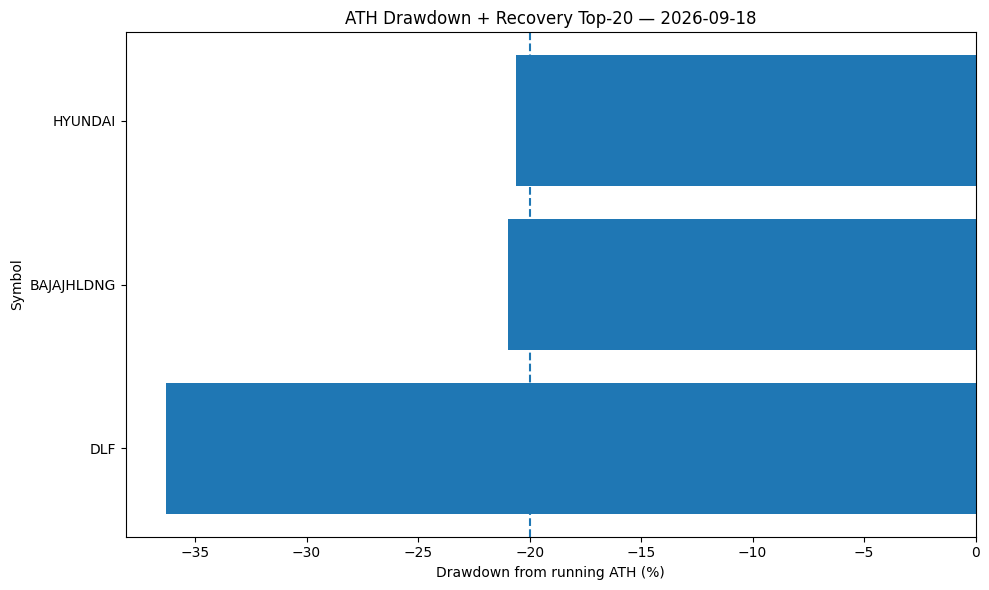

In [13]:
# 11. Visual diagnostic

if not top20.empty:
    chart = top20.sort_values("ath_drawdown")
    plt.figure(figsize=(10, 6))
    plt.barh(chart["symbol"], chart["ath_drawdown"] * 100)
    plt.axvline(-ATH_DRAWDOWN_MIN * 100, linestyle="--")
    plt.xlabel("Drawdown from running ATH (%)")
    plt.ylabel("Symbol")
    plt.title(f"ATH Drawdown + Recovery Top-{TOP_N} — {as_of.date()}")
    plt.tight_layout()
    plt.show()
else:
    print("No stocks currently satisfy both conditions.")



## 14. Export the current Top-N screen

In [14]:
# 14. Export this month's Top-N screen

stamp = as_of.strftime("%Y%m%d")
output_file = Path(f"ATH_Recovery_TopN_{stamp}.csv")

top20[[
    "rank", "symbol", "conviction", "Close", "running_ath",
    "ath_drawdown", "dma_200", "recovery_above_200dma_pct"
]].to_csv(output_file, index=False)

print(f"Saved: {output_file.resolve()}")



Saved: /content/ATH_Recovery_TopN_20260918.csv


## 15. Journey design and timing

## 15. Journey design and timing

The monthly journey is deliberately separated from the current-screen diagnostic. Purchases use the prior month-end screen and execute at the next month's first trading-day open.


## 16. Validate the journey window


In [15]:
# 17. Validate the journey window

start_ts = pd.Timestamp(START_DATE)
end_ts = pd.Timestamp(END_DATE)
if end_ts < start_ts:
    raise ValueError("END_DATE must be on or after START_DATE.")

journey_months = pd.period_range(start_ts, end_ts, freq="M")
n_months = len(journey_months)
'''
if EXPECTED_MONTHS is not None and n_months != EXPECTED_MONTHS:
    raise ValueError(
        f"START_DATE/END_DATE imply {n_months} calendar months, "
        f"but EXPECTED_MONTHS={EXPECTED_MONTHS}. Change the dates or EXPECTED_MONTHS."
    )
'''
print(f"Journey: {start_ts.date()} → {end_ts.date()}")
print(f"Calendar months: {n_months}")
print(f"Initial lump sum: {format_inr(INITIAL_LUMP_SUM)}")
print(f"Monthly SIP: {format_inr(MONTHLY_SIP)}")


Journey: 2014-10-01 → 2026-09-30
Calendar months: 144
Initial lump sum: ₹1,00,00,000
Monthly SIP: ₹1,00,000


## 17. Rebuild the historical signal series

In [16]:
# 19. Historical signal calculations

prices = prices.sort_values(["symbol", "date"]).copy()
prices["running_ath"] = prices.groupby("symbol")["Close"].cummax()
prices["ath_drawdown"] = prices["Close"] / prices["running_ath"] - 1
prices["dma_200"] = prices.groupby("symbol")["Close"].transform(
    lambda s: s.rolling(DMA_WINDOW, min_periods=DMA_WINDOW).mean()
)
prices["above_200dma"] = prices["Close"] >= prices["dma_200"]

# Daily month-end label.
prices["month"] = prices["date"].dt.to_period("M")

# Ensure static signal columns are present for the journey
# First, remove them if they already exist to avoid MergeError
cols_to_drop = ["conviction", "conviction_rank", "Category"]
prices = prices.drop(columns=[col for col in cols_to_drop if col in prices.columns])

prices = prices.merge(
    signals[["symbol", "conviction", "conviction_rank", "category"]],
    on="symbol",
    how="left"
)
prices = prices.rename(columns={"category": "Category"})

print(f"Usable price history: {prices['date'].min().date()} → {prices['date'].max().date()}")


Usable price history: 1991-01-02 → 2026-09-18


## 18. Point-in-time monthly screen helpers and journey calendar

In [17]:
# 20. Helper: monthly screen from a specified signal date

def screen_on_date(signal_date, top_n=TOP_N):
    """Return the strategy opportunity set known at signal_date."""
    d = pd.Timestamp(signal_date)
    snap = prices[prices["date"] == d].copy()
    if snap.empty:
        return pd.DataFrame()

    snap["passes_ath_drawdown"] = snap["ath_drawdown"] <= -ATH_DRAWDOWN_MIN
    snap["passes_recovery"] = snap["dma_200"].notna() & (snap["Close"] >= snap["dma_200"])
    eligible = snap[snap["passes_ath_drawdown"] & snap["passes_recovery"]].copy()

    # Canonical strategy rule: largest ATH drawdown first; X-LC is used
    # only as the tie-break, followed by symbol for deterministic ordering.
    eligible = eligible.sort_values(
        ["ath_drawdown", "conviction_rank", "symbol"],
        ascending=[True, True, True]
    ).reset_index(drop=True)
    eligible["rank"] = np.arange(1, len(eligible) + 1)
    eligible["distance_from_ath_pct"] = -eligible["ath_drawdown"]
    eligible["recovery_above_200dma_pct"] = eligible["Close"] / eligible["dma_200"] - 1
    return eligible.head(top_n).copy()

def last_trading_day_on_or_before(d):
    d = pd.Timestamp(d)
    valid = prices.loc[prices["date"] <= d, "date"]
    return valid.max() if not valid.empty else pd.NaT

def first_trading_day_on_or_after(d):
    d = pd.Timestamp(d)
    valid = prices.loc[prices["date"] >= d, "date"]
    return valid.min() if not valid.empty else pd.NaT

def month_end_trading_day(period):
    end = period.end_time.normalize()
    return last_trading_day_on_or_before(end)

def month_first_trading_day(period):
    return first_trading_day_on_or_after(period.start_time.normalize())


In [18]:
month_rows = []
for p in journey_months:
    month_start = p.start_time.normalize()
    month_end = p.end_time.normalize()
    first_td = month_first_trading_day(p)
    month_end_td = month_end_trading_day(p)
    prior_signal_td = last_trading_day_on_or_before(month_start - pd.Timedelta(days=1))
    screen_td = month_end_trading_day(p)
    # Purchases made during this month are based on the prior month's month-end screen.
    purchase_screen = prior_signal_td
    month_rows.append({
        "month": str(p),
        "month_period": p,
        "month_start": month_start,
        "month_end": month_end,
        "first_trading_day": first_td,
        "month_end_trading_day": month_end_td,
        "purchase_screen_date": purchase_screen,
        "month_end_screen_date": screen_td,
    })

calendar = pd.DataFrame(month_rows)
calendar = calendar[calendar["first_trading_day"].notna() & calendar["month_end_trading_day"].notna()].copy()
display(calendar[["month","first_trading_day","purchase_screen_date","month_end_trading_day"]].head())


,month,first_trading_day,purchase_screen_date,month_end_trading_day
0,2014-10,2014-10-01,2014-09-30,2014-10-31
1,2014-11,2014-11-03,2014-10-31,2014-11-28
2,2014-12,2014-12-01,2014-11-28,2014-12-31
3,2015-01,2015-01-01,2014-12-31,2015-01-30
4,2015-02,2015-02-02,2015-01-30,2015-02-27


## 19. Portfolio engine

The engine follows one monthly state transition: contribution → scheduled trims → new purchases → month-end valuation. All BUY/TRIM quantities are integer shares.

In [19]:

COST_RATE = TRANSACTION_COST_BPS / 10000
SLIPPAGE_RATE = SLIPPAGE_BPS / 10000

close_lookup = prices.set_index(["date", "symbol"])["Close"]
open_lookup = prices.set_index(["date", "symbol"])["Open"]
category_lookup = prices.set_index(["date", "symbol"])["Category"]

cash = 0.0
shares = {}  # symbol -> integer shares held
cashflows = []
trade_rows = []
opportunity_rows = []
month_rows_out = []
audit_rows = []

# Month-end position weights above this threshold trigger a partial trim next month.
trim_queue = set()


def market_value_at(date):
    total = 0.0
    details = []
    for symbol, qty in shares.items():
        try:
            px = float(close_lookup.loc[(date, symbol)])
        except KeyError:
            px = np.nan
        if pd.notna(px):
            mv = qty * px
            total += mv
            details.append((symbol, qty, px, mv))
    return total, details


def xirr(cashflows_df):
    cf = cashflows_df.dropna(subset=["date", "amount"]).copy()
    if len(cf) < 2 or not (cf["amount"] > 0).any() or not (cf["amount"] < 0).any():
        return np.nan
    dates = pd.to_datetime(cf["date"])
    amounts = cf["amount"].astype(float).to_numpy()
    t0 = dates.iloc[0]
    years = np.array([(d - t0).days / 365.25 for d in dates])
    def npv(r):
        if r <= -0.999999:
            return np.inf
        return np.sum(amounts / ((1 + r) ** years))
    lo, hi = -0.9999, 10.0
    flo, fhi = npv(lo), npv(hi)
    if np.sign(flo) == np.sign(fhi):
        for new_hi in [25.0, 50.0, 100.0]:
            hi, fhi = new_hi, npv(new_hi)
            if np.sign(flo) != np.sign(fhi):
                break
    if np.sign(flo) == np.sign(fhi):
        return np.nan
    for _ in range(200):
        mid = (lo + hi) / 2
        fm = npv(mid)
        if abs(fm) < 1e-7:
            return mid
        if np.sign(fm) == np.sign(flo):
            lo, flo = mid, fm
        else:
            hi, fhi = mid, fm
    return (lo + hi) / 2

for month_number, (_, row) in enumerate(calendar.reset_index(drop=True).iterrows()):
    month = row["month"]
    first_td = row["first_trading_day"]
    month_end_td = row["month_end_trading_day"]
    purchase_screen_date = row["purchase_screen_date"]

    contribution = 0.0
    if month_number == 0:
        contribution += float(INITIAL_LUMP_SUM)
        if SIP_IN_FIRST_MONTH:
            contribution += float(MONTHLY_SIP)
    else:
        contribution += float(MONTHLY_SIP)
    cash += contribution

    if contribution > 0:
        cashflows.append({"date": first_td, "amount": -contribution, "type": "contribution"})

    opp = screen_on_date(purchase_screen_date, TOP_N) if pd.notna(purchase_screen_date) else pd.DataFrame()
    if not opp.empty:
        for _, r in opp.iterrows():
            opportunity_rows.append({
                "month": month,
                "screen_date": purchase_screen_date,
                "rank": int(r["rank"]),
                "symbol": r["symbol"],
                "conviction": r["conviction"],
                "category": r["Category"],
                "close_on_screen": float(r["Close"]),
                "ath_drawdown": float(r["ath_drawdown"]),
                "above_200dma_pct": float(r["recovery_above_200dma_pct"]),
            })

    # Value existing holdings at the first trading-day open.
    pre_mv = 0.0
    first_day_values = {}
    first_day_sectors = {}
    for symbol, qty in shares.items():
        try:
            px = float(open_lookup.loc[(first_td, symbol)])
            sector = str(category_lookup.loc[(first_td, symbol)])
        except KeyError:
            px, sector = np.nan, "Unknown"
        if pd.notna(px) and px > 0:
            mv = qty * px
            pre_mv += mv
            first_day_values[symbol] = mv
            first_day_sectors[sector] = first_day_sectors.get(sector, 0.0) + mv

    pre_equity = cash + pre_mv

    # ------------------------------------------------------------
    # Position-risk trims: only positions that breached the hard
    # concentration threshold at the PREVIOUS month-end are trimmed.
    # This keeps the 7% cap as an entry/addition cap while preventing
    # exceptional winners from becoming unbounded concentration risk.
    # ------------------------------------------------------------
    if month_number > 0 and trim_queue and pre_equity > 0:
        for symbol in sorted(trim_queue):
            qty_existing = int(shares.get(symbol, 0))
            if qty_existing <= 0 or symbol not in first_day_values:
                continue
            open_px = float(open_lookup.loc[(first_td, symbol)])
            current_mv = qty_existing * open_px
            target_mv = pre_equity * POSITION_TRIM_TARGET_PCT
            trim_value = max(0.0, current_mv - target_mv)
            if trim_value <= 1e-8:
                continue

            effective_px = open_px * (1 - SLIPPAGE_RATE)
            # Indian cash-equity trading uses whole shares only.
            qty_to_sell = min(qty_existing, int(np.floor(trim_value / effective_px + 1e-12)))
            gross_proceeds = qty_to_sell * effective_px
            transaction_cost = gross_proceeds * COST_RATE
            net_proceeds = gross_proceeds - transaction_cost
            if qty_to_sell <= 0 or net_proceeds <= 0:
                continue

            shares[symbol] = int(qty_existing - qty_to_sell)
            cash += net_proceeds
            trade_rows.append({
                "month": month,
                "trade_date": first_td,
                "screen_date": purchase_screen_date,
                "rank": np.nan,
                "symbol": symbol,
                "conviction": "Position Risk Trim",
                "category": str(category_lookup.loc[(first_td, symbol)]),
                "action": "TRIM",
                "shares_bought": -qty_to_sell,
                "open_price": open_px,
                "effective_price": effective_px,
                "gross_investment": -gross_proceeds,
                "transaction_cost": transaction_cost,
                "total_cash_out": -net_proceeds,
                "post_trade_cap": pre_equity * POSITION_HARD_PCT,
                "risk_threshold": POSITION_HARD_PCT,
                "trim_target": POSITION_TRIM_TARGET_PCT,
            })

            # Refresh first-day value after the trim so subsequent purchases
            # use the correct available cash and position size.
            first_day_values[symbol] = shares[symbol] * open_px

        trim_queue = set()

    # Recalculate equity/caps after any risk trims and before new purchases.
    pre_mv = sum(first_day_values.values())
    pre_equity = cash + pre_mv
    cap_value = pre_equity * MAX_POSITION_PCT
    sector_cap_value = pre_equity * MAX_SECTOR_PCT
    available = cash

    sector_values = {}
    for held_symbol, held_qty in shares.items():
        try:
            held_px = float(open_lookup.loc[(first_td, held_symbol)])
            held_sector = str(category_lookup.loc[(first_td, held_symbol)])
        except KeyError:
            continue
        if pd.notna(held_px) and held_px > 0:
            sector_values[held_sector] = sector_values.get(held_sector, 0.0) + held_qty * held_px

    if not opp.empty and available > 0:
        for _, r in opp.iterrows():
            symbol = r["symbol"]
            if symbol not in shares and len(shares) >= MAX_HOLDINGS:
                break
            if symbol not in set(signals["symbol"]):
                continue
            qty_existing = int(shares.get(symbol, 0))
            if qty_existing > 0 and not ALLOW_REPEAT_BUYS:
                continue
            sector = str(r["Category"])
            try:
                open_px = float(open_lookup.loc[(first_td, symbol)])
            except KeyError:
                continue
            if not np.isfinite(open_px) or open_px <= 0:
                continue

            existing_mv = qty_existing * open_px
            room = max(0.0, cap_value - existing_mv)
            current_sector_value = sector_values.get(sector, 0.0)
            sector_room = max(0.0, sector_cap_value - current_sector_value)
            gross_budget = min(room, sector_room, available)
            if gross_budget <= 1e-8:
                continue

            effective_px = open_px * (1 + SLIPPAGE_RATE)

            # Indian cash-equity trades must use whole shares.
            # Position/sector room is measured on the consideration value;
            # transaction costs are additional cash required.
            qty = int(np.floor(
                min(
                    gross_budget / effective_px,
                    available / (effective_px * (1 + COST_RATE))
                ) + 1e-12
            ))
            consideration = qty * effective_px
            transaction_cost = consideration * COST_RATE
            total_cash = consideration + transaction_cost

            if qty <= 0 or total_cash <= 0:
                continue

            shares[symbol] = int(qty_existing + qty)
            sector_values[sector] = sector_values.get(sector, 0.0) + consideration
            cash -= total_cash
            available = cash
            trade_rows.append({
                "month": month,
                "trade_date": first_td,
                "screen_date": purchase_screen_date,
                "rank": int(r["rank"]),
                "symbol": symbol,
                "conviction": r["conviction"],
                "category": sector,
                "action": "BUY",
                "shares_bought": qty,
                "open_price": open_px,
                "effective_price": effective_px,
                "gross_investment": consideration,
                "transaction_cost": transaction_cost,
                "total_cash_out": total_cash,
                "post_trade_cap": cap_value,
                "risk_threshold": np.nan,
                "trim_target": np.nan,
            })
            if cash <= 1e-8:
                break

    if not all(float(qty).is_integer() and qty >= 0 for qty in shares.values()):
        raise AssertionError(f"Integer-share invariant failed in {month}: {shares}")
    if cash < -1e-6:
        raise AssertionError(f"Negative cash invariant failed in {month}: {cash}")

    equity_value, holding_details = market_value_at(month_end_td)
    portfolio_value = cash + equity_value
    contributed = INITIAL_LUMP_SUM + MONTHLY_SIP * (month_number if not SIP_IN_FIRST_MONTH else month_number + 1)
    profit = portfolio_value - contributed
    profit_pct = profit / contributed if contributed else np.nan

    external_cf = [x for x in cashflows if x["type"] == "contribution"]
    cf = pd.DataFrame(external_cf + [{"date": month_end_td, "amount": portfolio_value, "type": "terminal_mark"}])
    current_xirr = xirr(cf)

    invested_pct = equity_value / portfolio_value if portfolio_value else 0.0
    month_sector_values = {}
    month_stock_weights = {}
    for symbol, qty, px, mv in holding_details:
        try:
            sector = str(category_lookup.loc[(month_end_td, symbol)])
        except KeyError:
            sector = "Unknown"
        month_sector_values[sector] = month_sector_values.get(sector, 0.0) + mv
        month_stock_weights[symbol] = mv / portfolio_value if portfolio_value else 0.0

    max_sector_weight = (max(month_sector_values.values()) / portfolio_value) if month_sector_values and portfolio_value else 0.0
    max_sector_name = max(month_sector_values, key=month_sector_values.get) if month_sector_values else None
    max_stock_weight = max(month_stock_weights.values()) if month_stock_weights else 0.0
    max_stock_name = max(month_stock_weights, key=month_stock_weights.get) if month_stock_weights else None

    # Queue any hard-limit breaches observed at month-end for the next
    # month's first trading day. Review-zone positions are reported only.
    trim_queue = {s for s, w in month_stock_weights.items() if w > POSITION_HARD_PCT}

    cumulative_deployed = sum(t["total_cash_out"] for t in trade_rows if t["trade_date"] <= month_end_td and t["action"] == "BUY")
    cumulative_trim_proceeds = -sum(t["total_cash_out"] for t in trade_rows if t["trade_date"] <= month_end_td and t["action"] == "TRIM")
    month_rows_out.append({
        "month": month,
        "screen_date_for_month_end": row["month_end_screen_date"],
        "purchase_screen_date": purchase_screen_date,
        "first_trading_day": first_td,
        "month_end": month_end_td,
        "contribution_this_month": contribution,
        "cumulative_contributed": contributed,
        "gross_invested_value": equity_value,
        "cumulative_deployed": cumulative_deployed,
        "cumulative_trim_proceeds": cumulative_trim_proceeds,
        "cash_left": cash,
        "portfolio_value": portfolio_value,
        "invested_pct": invested_pct,
        "max_stock_weight": max_stock_weight,
        "max_stock": max_stock_name,
        "max_sector_weight": max_sector_weight,
        "max_sector": max_sector_name,
        "absolute_profit": profit,
        "absolute_profit_pct": profit_pct,
        "xirr": current_xirr,
        "num_holdings": len([x for x in holding_details if x[3] > 0]),
        "buy_events_this_month": sum(1 for t in trade_rows if t["month"] == month and t["action"] == "BUY"),
        "trim_events_this_month": sum(1 for t in trade_rows if t["month"] == month and t["action"] == "TRIM"),
        "eligible_opportunities": len(opp),
    })

    # Compact accounting/risk audit for this month.
    month_trades = [t for t in trade_rows if t["month"] == month]
    buy_cash = sum(t["total_cash_out"] for t in month_trades if t["action"] == "BUY")
    trim_cash = -sum(t["total_cash_out"] for t in month_trades if t["action"] == "TRIM")
    integer_ok = all(float(qty).is_integer() and qty >= 0 for qty in shares.values())
    cash_ok = cash >= -1e-6
    audit_rows.append({
        "month": month,
        "integer_shares_ok": integer_ok,
        "negative_cash_ok": cash_ok,
        "buy_cash": buy_cash,
        "trim_proceeds": trim_cash,
        "closing_cash": cash,
        "portfolio_value": portfolio_value,
        "buy_events": sum(1 for t in month_trades if t["action"] == "BUY"),
        "trim_events": sum(1 for t in month_trades if t["action"] == "TRIM"),
    })

monthly_journey = pd.DataFrame(month_rows_out)
trades = pd.DataFrame(trade_rows)
opportunities = pd.DataFrame(opportunity_rows)

print(f"Months simulated: {len(monthly_journey)}")
print(f"Buy events: {sum(trades['action'].eq('BUY')) if not trades.empty else 0:,}")
print(f"Trim events: {sum(trades['action'].eq('TRIM')) if not trades.empty else 0:,}")
print(f"Opportunity observations: {len(opportunities):,}")


# Final engine objects
audit = pd.DataFrame(audit_rows)


Months simulated: 144
Buy events: 95
Trim events: 5
Opportunity observations: 809


## 20. Portfolio validation and audit

In [20]:
def run_portfolio_audit():
    checks = []
    checks.append(("Configuration valid", True))
    checks.append(("Expected journey months", len(monthly_journey) == len(journey_months)))
    checks.append(("Integer shares throughout", bool(audit["integer_shares_ok"].all()) if not audit.empty else True))
    checks.append(("No negative cash", bool(audit["negative_cash_ok"].all()) if not audit.empty else True))
    checks.append(("No negative holdings", all(float(q) >= 0 for q in shares.values())))
    checks.append(("No fractional holdings", all(float(q).is_integer() for q in shares.values())))
    checks.append(("No look-ahead in purchase screens", bool((pd.to_datetime(calendar["purchase_screen_date"]) < pd.to_datetime(calendar["first_trading_day"])).all())) )
    checks.append(("Trade ledger present", True))

    audit_table = pd.DataFrame(checks, columns=["check", "passed"])
    display(audit_table.style.format({"passed": lambda x: "✓" if x else "✗"}))
    if not audit_table["passed"].all():
        failed = audit_table.loc[~audit_table["passed"], "check"].tolist()
        raise AssertionError(f"Portfolio audit failed: {failed}")
    print("Audit status: PASS")

run_portfolio_audit()
print(f"Data fingerprint: {DATA_FINGERPRINT}")


,check,passed
0,Configuration valid,✓
1,Expected journey months,✓
2,Integer shares throughout,✓
3,No negative cash,✓
4,No negative holdings,✓
5,No fractional holdings,✓
6,No look-ahead in purchase screens,✓
7,Trade ledger present,✓


Audit status: PASS
Data fingerprint: 181f9c44d3cdd4d5


## 21. Month-by-month journey results

In [21]:
# 25. Main month-by-month table

journey_view = monthly_journey.copy()
display(journey_view.style.format({
    "contribution_this_month": format_inr,
    "cumulative_contributed": format_inr,
    "cumulative_deployed": format_inr,
    "gross_invested_value": format_inr,
    "cash_left": format_inr,
    "portfolio_value": format_inr,
    "invested_pct": "{:.1%}",
    "max_sector_weight": "{:.1%}",
    "absolute_profit": format_inr,
    "absolute_profit_pct": "{:.1%}",
    "xirr": "{:.1%}",
}))


,month,screen_date_for_month_end,purchase_screen_date,first_trading_day,month_end,contribution_this_month,cumulative_contributed,gross_invested_value,cumulative_deployed,cumulative_trim_proceeds,cash_left,portfolio_value,invested_pct,max_stock_weight,max_stock,max_sector_weight,max_sector,absolute_profit,absolute_profit_pct,xirr,num_holdings,buy_events_this_month,trim_events_this_month,eligible_opportunities
0,2014-10,2014-10-31 00:00:00,2014-09-30 00:00:00,2014-10-01 00:00:00,2014-10-31 00:00:00,"₹1,00,00,000","₹1,00,00,000","₹63,08,444","₹62,05,388",0.000000,"₹37,94,612","₹1,01,03,056",62.4%,0.076547,SBIN,19.7%,FINANCE,"₹1,03,056",1.0%,13.3%,9,9,0,9
1,2014-11,2014-11-28 00:00:00,2014-10-31 00:00:00,2014-11-03 00:00:00,2014-11-28 00:00:00,"₹1,00,000","₹1,01,00,000","₹73,97,155","₹70,24,772",0.000000,"₹30,75,228","₹1,04,72,384",70.6%,0.087815,SBIN,20.8%,FINANCE,"₹3,72,384",3.7%,25.8%,10,5,0,9
2,2014-12,2014-12-31 00:00:00,2014-11-28 00:00:00,2014-12-01 00:00:00,2014-12-31 00:00:00,"₹1,00,000","₹1,02,00,000","₹76,52,037","₹72,15,839",0.000000,"₹29,84,161","₹1,06,36,198",71.9%,0.084223,BAJFINANCE,22.4%,FINANCE,"₹4,36,198",4.3%,18.5%,10,5,0,10
3,2015-01,2015-01-30 00:00:00,2014-12-31 00:00:00,2015-01-01 00:00:00,2015-01-30 00:00:00,"₹1,00,000","₹1,03,00,000","₹81,35,420","₹72,99,823",0.000000,"₹30,00,177","₹1,11,35,597",73.1%,0.093529,BAJFINANCE,23.5%,FINANCE,"₹8,35,597",8.1%,27.0%,10,2,0,7
4,2015-02,2015-02-27 00:00:00,2015-01-30 00:00:00,2015-02-02 00:00:00,2015-02-27 00:00:00,"₹1,00,000","₹1,04,00,000","₹89,23,750","₹81,60,953",0.000000,"₹22,39,047","₹1,11,62,797",79.9%,0.094603,BAJFINANCE,23.4%,FINANCE,"₹7,62,797",7.3%,19.4%,11,2,0,8
5,2015-03,2015-03-31 00:00:00,2015-02-27 00:00:00,2015-03-02 00:00:00,2015-03-31 00:00:00,"₹1,00,000","₹1,05,00,000","₹85,93,359","₹81,60,953",0.000000,"₹23,39,047","₹1,09,32,406",78.6%,0.096629,BAJFINANCE,23.4%,FINANCE,"₹4,32,406",4.1%,8.7%,11,0,0,5
6,2015-04,2015-04-30 00:00:00,2015-03-31 00:00:00,2015-04-01 00:00:00,2015-04-30 00:00:00,"₹1,00,000","₹1,06,00,000","₹84,97,048","₹81,60,953",0.000000,"₹24,39,047","₹1,09,36,095",77.7%,0.095088,BAJFINANCE,23.4%,FINANCE,"₹3,36,095",3.2%,5.7%,11,0,0,6
7,2015-05,2015-05-29 00:00:00,2015-04-30 00:00:00,2015-05-04 00:00:00,2015-05-29 00:00:00,"₹1,00,000","₹1,07,00,000","₹87,20,647","₹81,60,953",0.000000,"₹25,39,047","₹1,12,59,695",77.5%,0.096289,BAJFINANCE,23.8%,FINANCE,"₹5,59,695",5.2%,8.4%,11,0,0,5
8,2015-06,2015-06-30 00:00:00,2015-05-29 00:00:00,2015-06-01 00:00:00,2015-06-30 00:00:00,"₹1,00,000","₹1,08,00,000","₹89,45,175","₹81,60,953",0.000000,"₹26,39,047","₹1,15,84,222",77.2%,0.120823,BAJFINANCE,26.4%,FINANCE,"₹7,84,222",7.3%,10.3%,11,0,0,5
9,2015-07,2015-07-31 00:00:00,2015-06-30 00:00:00,2015-07-01 00:00:00,2015-07-31 00:00:00,"₹1,00,000","₹1,09,00,000","₹1,02,43,845","₹90,23,014",0.000000,"₹18,76,986","₹1,21,20,831",84.5%,0.117318,BAJFINANCE,27.3%,FINANCE,"₹12,20,831",11.2%,14.3%,12,2,0,6


## 22. Opportunity history

In [22]:
# 27. Monthly opportunity table

if opportunities.empty:
    print("No qualifying opportunities in the journey window.")
else:
    display(opportunities.style.format({
        "close_on_screen": lambda x: format_inr(x, 2),
        "ath_drawdown": "{:.1%}",
        "above_200dma_pct": "{:.1%}",
    }))


,month,screen_date,rank,symbol,conviction,category,close_on_screen,ath_drawdown,above_200dma_pct
0,2014-10,2014-09-30 00:00:00,1,BAJAJFINSV,X-LC,FINANCE,₹112.21,-96.5%,33.9%
1,2014-10,2014-09-30 00:00:00,2,BAJFINANCE,X-LC,FINANCE,₹26.09,-89.7%,42.3%
2,2014-10,2014-09-30 00:00:00,3,GRASIM,H-LC,TEXTILES,₹511.97,-47.1%,18.5%
3,2014-10,2014-09-30 00:00:00,4,NESTLEIND,X-LC,FMCG,₹259.85,-44.6%,16.5%
4,2014-10,2014-09-30 00:00:00,5,BAJAJHLDNG,X-LC,FINANCE,"₹1,152.51",-43.5%,26.2%
5,2014-10,2014-09-30 00:00:00,6,HINDALCO,H-LC,METALS,₹144.34,-34.8%,9.2%
6,2014-10,2014-09-30 00:00:00,7,ABB,H-LC,ELECTRICAL,₹984.12,-28.4%,30.9%
7,2014-10,2014-09-30 00:00:00,8,BHARTIARTL,H-LC,TELECOM,₹339.71,-26.2%,20.9%
8,2014-10,2014-09-30 00:00:00,9,SBIN,X-LC,BANKS,₹214.14,-24.0%,15.1%
9,2014-11,2014-10-31 00:00:00,1,BAJAJFINSV,X-LC,FINANCE,₹106.12,-96.7%,21.9%


## 23. Trade ledger

In [23]:
# 29. Trade ledger

if trades.empty:
    print("No trades were generated.")
else:
    display(trades.style.format({
        "shares_bought": "{:,.0f}",
        "open_price": lambda x: format_inr(x, 2),
        "effective_price": lambda x: format_inr(x, 2),
        "gross_investment": format_inr,
        "transaction_cost": format_inr,
        "total_cash_out": format_inr,
        "post_trade_cap": format_inr,
    }))


,month,trade_date,screen_date,rank,symbol,conviction,category,action,shares_bought,open_price,effective_price,gross_investment,transaction_cost,total_cash_out,post_trade_cap,risk_threshold,trim_target
0,2014-10,2014-10-01 00:00:00,2014-09-30 00:00:00,1.000000,BAJAJFINSV,X-LC,FINANCE,BUY,"6,266",₹111.64,₹111.70,"₹6,99,911",₹700,"₹7,00,611","₹7,00,000",nan,nan
1,2014-10,2014-10-01 00:00:00,2014-09-30 00:00:00,2.000000,BAJFINANCE,X-LC,FINANCE,BUY,"26,820",₹26.09,₹26.10,"₹6,99,988",₹700,"₹7,00,688","₹7,00,000",nan,nan
2,2014-10,2014-10-01 00:00:00,2014-09-30 00:00:00,3.000000,GRASIM,H-LC,TEXTILES,BUY,"1,362",₹513.63,₹513.89,"₹6,99,919",₹700,"₹7,00,619","₹7,00,000",nan,nan
3,2014-10,2014-10-01 00:00:00,2014-09-30 00:00:00,4.000000,NESTLEIND,X-LC,FMCG,BUY,"2,666",₹262.39,₹262.52,"₹6,99,869",₹700,"₹7,00,569","₹7,00,000",nan,nan
4,2014-10,2014-10-01 00:00:00,2014-09-30 00:00:00,5.000000,BAJAJHLDNG,X-LC,FINANCE,BUY,522,"₹1,148.75","₹1,149.32","₹5,99,945",₹600,"₹6,00,545","₹7,00,000",nan,nan
5,2014-10,2014-10-01 00:00:00,2014-09-30 00:00:00,6.000000,HINDALCO,H-LC,METALS,BUY,"4,895",₹142.92,₹142.99,"₹6,99,931",₹700,"₹7,00,631","₹7,00,000",nan,nan
6,2014-10,2014-10-01 00:00:00,2014-09-30 00:00:00,7.000000,ABB,H-LC,ELECTRICAL,BUY,705,₹992.29,₹992.79,"₹6,99,914",₹700,"₹7,00,614","₹7,00,000",nan,nan
7,2014-10,2014-10-01 00:00:00,2014-09-30 00:00:00,8.000000,BHARTIARTL,H-LC,TELECOM,BUY,"2,065",₹338.70,₹338.87,"₹6,99,769",₹700,"₹7,00,468","₹7,00,000",nan,nan
8,2014-10,2014-10-01 00:00:00,2014-09-30 00:00:00,9.000000,SBIN,X-LC,BANKS,BUY,"3,268",₹214.07,₹214.18,"₹6,99,943",₹700,"₹7,00,643","₹7,00,000",nan,nan
9,2014-11,2014-11-03 00:00:00,2014-10-31 00:00:00,1.000000,BAJAJFINSV,X-LC,FINANCE,BUY,471,₹106.12,₹106.17,"₹50,006",₹50,"₹50,056","₹7,14,937",nan,nan


## 24. Month-end holdings and compact portfolio snapshot

In [24]:
# 30. End-of-month portfolio holdings

holding_rows = []
for _, mr in monthly_journey.iterrows():
    d = mr["month_end"]
    for symbol, qty in shares.items():
        try:
            px = float(close_lookup.loc[(d, symbol)])
        except KeyError:
            continue
        # Reconstruct shares held through the trade ledger up to this month-end.
        if not trades.empty:
            q = trades.loc[trades["trade_date"] <= d].groupby("symbol")["shares_bought"].sum().get(symbol, 0.0)
        else:
            q = 0.0
        if q > 0:
            holding_rows.append({
                "month": mr["month"],
                "month_end": d,
                "symbol": symbol,
                "shares": q,
                "close": px,
                "market_value": q * px,
                "portfolio_weight": (q * px) / mr["portfolio_value"] if mr["portfolio_value"] else np.nan,
            })

monthly_holdings = pd.DataFrame(holding_rows)
if not monthly_holdings.empty:
    display(monthly_holdings.style.format({
        "shares": "{:,.0f}",
        "close": lambda x: format_inr(x, 2),
        "market_value": format_inr,
        "portfolio_weight": "{:.1%}",
    }))
else:
    print("No holdings to display.")


,month,month_end,symbol,shares,close,market_value,portfolio_weight
0,2014-10,2014-10-31 00:00:00,BAJAJFINSV,"6,266",₹106.12,"₹6,64,925",6.6%
1,2014-10,2014-10-31 00:00:00,BAJFINANCE,"26,820",₹26.93,"₹7,22,136",7.1%
2,2014-10,2014-10-31 00:00:00,GRASIM,"1,362",₹506.15,"₹6,89,380",6.8%
3,2014-10,2014-10-31 00:00:00,NESTLEIND,"2,666",₹272.41,"₹7,26,237",7.2%
4,2014-10,2014-10-31 00:00:00,BAJAJHLDNG,522,"₹1,147.55","₹5,99,019",5.9%
5,2014-10,2014-10-31 00:00:00,HINDALCO,"4,895",₹150.74,"₹7,37,896",7.3%
6,2014-10,2014-10-31 00:00:00,ABB,705,₹999.86,"₹7,04,902",7.0%
7,2014-10,2014-10-31 00:00:00,BHARTIARTL,"2,065",₹334.43,"₹6,90,589",6.8%
8,2014-10,2014-10-31 00:00:00,SBIN,"3,268",₹236.65,"₹7,73,358",7.7%
9,2014-11,2014-11-28 00:00:00,BAJAJFINSV,"6,737",₹114.29,"₹7,69,945",7.4%


In [25]:
# 36. Detailed month-end holdings snapshot

snapshot_rows = []
if not trades.empty:
    for _, mr in monthly_journey.iterrows():
        d = mr["month_end"]
        prior = trades[trades["trade_date"] <= d]
        for symbol, g in prior.groupby("symbol"):
            qty = g["shares_bought"].sum()
            buy_cash = g.loc[g["action"] == "BUY", "total_cash_out"].sum() if "action" in g.columns else g["total_cash_out"].sum()
            trim_proceeds = -g.loc[g["action"] == "TRIM", "total_cash_out"].sum() if "action" in g.columns else 0.0
            try:
                px = float(close_lookup.loc[(d, symbol)])
            except KeyError:
                continue
            try:
                sector = str(category_lookup.loc[(d, symbol)])
            except KeyError:
                sector = str(g["category"].iloc[-1]) if "category" in g.columns else "Unknown"
            mv = qty * px
            pnl = mv + trim_proceeds - buy_cash
            snapshot_rows.append({
                "month": mr["month"], "month_end": d, "symbol": symbol,
                "category": sector, "conviction": (g.loc[g["action"] == "BUY", "conviction"].iloc[-1] if "action" in g.columns and (g["action"] == "BUY").any() else g["conviction"].iloc[-1]),
                "shares": qty, "month_end_price": px, "market_value": mv,
                "portfolio_weight": mv / mr["portfolio_value"] if mr["portfolio_value"] else np.nan,
                "cumulative_total_cash_out": buy_cash,
                "cumulative_trim_proceeds": trim_proceeds,
                "unrealized_pnl": pnl,
                "unrealized_pnl_pct": pnl / buy_cash if buy_cash else np.nan,
                "net_pnl_after_trims": pnl,
                "net_pnl_after_trims_pct": pnl / buy_cash if buy_cash else np.nan,
            })

monthly_holdings_snapshot = pd.DataFrame(snapshot_rows)
if monthly_holdings_snapshot.empty:
    print("No month-end holdings were generated.")
else:
    monthly_holdings_snapshot = monthly_holdings_snapshot.sort_values(["month_end","market_value"], ascending=[True,False]).reset_index(drop=True)
    display(monthly_holdings_snapshot.style.format({
        "shares":"{:,.0f}", "month_end_price":lambda x: format_inr(x, 2), "market_value":format_inr,
        "portfolio_weight":"{:.1%}", "cumulative_total_cash_out":format_inr,
        "unrealized_pnl":format_inr, "unrealized_pnl_pct":"{:.1%}"
    }))


,month,month_end,symbol,category,conviction,shares,month_end_price,market_value,portfolio_weight,cumulative_total_cash_out,cumulative_trim_proceeds,unrealized_pnl,unrealized_pnl_pct,net_pnl_after_trims,net_pnl_after_trims_pct
0,2014-10,2014-10-31 00:00:00,SBIN,BANKS,X-LC,"3,268",₹236.65,"₹7,73,358",7.7%,"₹7,00,643",-0.000000,"₹72,715",10.4%,72715.055733,0.103783
1,2014-10,2014-10-31 00:00:00,HINDALCO,METALS,H-LC,"4,895",₹150.74,"₹7,37,896",7.3%,"₹7,00,631",-0.000000,"₹37,265",5.3%,37264.965928,0.053188
2,2014-10,2014-10-31 00:00:00,NESTLEIND,FMCG,X-LC,"2,666",₹272.41,"₹7,26,237",7.2%,"₹7,00,569",-0.000000,"₹25,668",3.7%,25668.397746,0.036639
3,2014-10,2014-10-31 00:00:00,BAJFINANCE,FINANCE,X-LC,"26,820",₹26.93,"₹7,22,136",7.1%,"₹7,00,688",-0.000000,"₹21,449",3.1%,21448.814894,0.030611
4,2014-10,2014-10-31 00:00:00,ABB,ELECTRICAL,H-LC,705,₹999.86,"₹7,04,902",7.0%,"₹7,00,614",-0.000000,"₹4,288",0.6%,4287.901571,0.006120
5,2014-10,2014-10-31 00:00:00,BHARTIARTL,TELECOM,H-LC,"2,065",₹334.43,"₹6,90,589",6.8%,"₹7,00,468",-0.000000,"₹-9,879",-1.4%,-9878.818185,-0.014103
6,2014-10,2014-10-31 00:00:00,GRASIM,TEXTILES,H-LC,"1,362",₹506.15,"₹6,89,380",6.8%,"₹7,00,619",-0.000000,"₹-11,239",-1.6%,-11238.842733,-0.016041
7,2014-10,2014-10-31 00:00:00,BAJAJFINSV,FINANCE,X-LC,"6,266",₹106.12,"₹6,64,925",6.6%,"₹7,00,611",-0.000000,"₹-35,686",-5.1%,-35685.553133,-0.050935
8,2014-10,2014-10-31 00:00:00,BAJAJHLDNG,FINANCE,X-LC,522,"₹1,147.55","₹5,99,019",5.9%,"₹6,00,545",-0.000000,"₹-1,526",-0.3%,-1526.172730,-0.002541
9,2014-11,2014-11-28 00:00:00,SBIN,BANKS,X-LC,"3,268",₹281.40,"₹9,19,629",8.8%,"₹7,00,643",-0.000000,"₹2,18,986",31.3%,218985.930672,0.312550


In [26]:
compact_rows = []
if not monthly_holdings_snapshot.empty:
    for month, g in monthly_holdings_snapshot.groupby("month", sort=False):
        g = g.sort_values("market_value", ascending=False)
        m = monthly_journey.loc[monthly_journey["month"] == month].iloc[0]
        holdings_text = " | ".join(f"{r.symbol} [{r.category}] {r.portfolio_weight:.1%} {format_inr(r.market_value)}" for r in g.itertuples())
        compact_rows.append({
            "month": month, "portfolio_value": m["portfolio_value"], "cash_left": m["cash_left"],
            "holdings_count": len(g), "max_stock_weight": g["portfolio_weight"].max(),
            "max_sector_weight": m["max_sector_weight"], "holdings": holdings_text
        })
compact_monthly_snapshot = pd.DataFrame(compact_rows)
display(compact_monthly_snapshot)


,month,portfolio_value,cash_left,holdings_count,max_stock_weight,max_sector_weight,holdings
0,2014-10,1.010306e+07,3.794612e+06,9,0.076547,0.196582,"SBIN [BANKS] 7.7% ₹7,73,358 | HINDALCO [METALS..."
1,2014-11,1.047238e+07,3.075228e+06,10,0.087815,0.208419,"SBIN [BANKS] 8.8% ₹9,19,629 | BAJFINANCE [FINA..."
2,2014-12,1.063620e+07,2.984161e+06,10,0.084223,0.223514,"BAJFINANCE [FINANCE] 8.4% ₹8,95,812 | SBIN [BA..."
3,2015-01,1.113560e+07,3.000177e+06,10,0.093529,0.235046,"BAJFINANCE [FINANCE] 9.4% ₹10,41,499 | BAJAJFI..."
4,2015-02,1.116280e+07,2.239047e+06,11,0.094603,0.233679,"BAJFINANCE [FINANCE] 9.5% ₹10,56,039 | BAJAJFI..."
...,...,...,...,...,...,...,...
139,2026-05,1.311669e+08,1.004975e+05,15,0.095665,0.193534,"BHARTIARTL [TELECOM] 9.6% ₹1,25,48,142 | HINDA..."
140,2026-06,1.318780e+08,2.004975e+05,15,0.096346,0.202992,"BHARTIARTL [TELECOM] 9.6% ₹1,27,05,937 | BAJFI..."
141,2026-07,1.405483e+08,3.004975e+05,15,0.097472,0.214005,"BHARTIARTL [TELECOM] 9.7% ₹1,36,99,484 | BAJFI..."
142,2026-08,1.440251e+08,4.004975e+05,15,0.103107,0.202746,"BOSCHLTD [AUTO] 10.3% ₹1,48,50,000 | BHARTIART..."


## 25. Sector exposure by month

In [27]:
sector_rows = []
if not monthly_holdings_snapshot.empty:
    for (month, category), g in monthly_holdings_snapshot.groupby(["month","category"]):
        pv = monthly_journey.loc[monthly_journey["month"] == month, "portfolio_value"].iloc[0]
        sector_rows.append({
            "month":month,
            "category":category,
            "market_value":g["market_value"].sum(),
            "portfolio_weight":g["market_value"].sum()/pv if pv else np.nan,
            "stocks_in_sector":g["symbol"].nunique()
        })
sector_snapshot = pd.DataFrame(sector_rows).sort_values(["month","market_value"], ascending=[True,False])
if not sector_snapshot.empty:
    display(sector_snapshot.style.format({"market_value":format_inr,"portfolio_weight":"{:.1%}"}))


,month,category,market_value,portfolio_weight,stocks_in_sector
2,2014-10,FINANCE,"₹19,86,081",19.7%,3
0,2014-10,BANKS,"₹7,73,358",7.7%,1
4,2014-10,METALS,"₹7,37,896",7.3%,1
3,2014-10,FMCG,"₹7,26,237",7.2%,1
1,2014-10,ELECTRICAL,"₹7,04,902",7.0%,1
5,2014-10,TELECOM,"₹6,90,589",6.8%,1
6,2014-10,TEXTILES,"₹6,89,380",6.8%,1
9,2014-11,FINANCE,"₹21,82,642",20.8%,3
7,2014-11,BANKS,"₹9,19,629",8.8%,1
11,2014-11,METALS,"₹7,84,550",7.5%,1


## 26. Portfolio journey charts

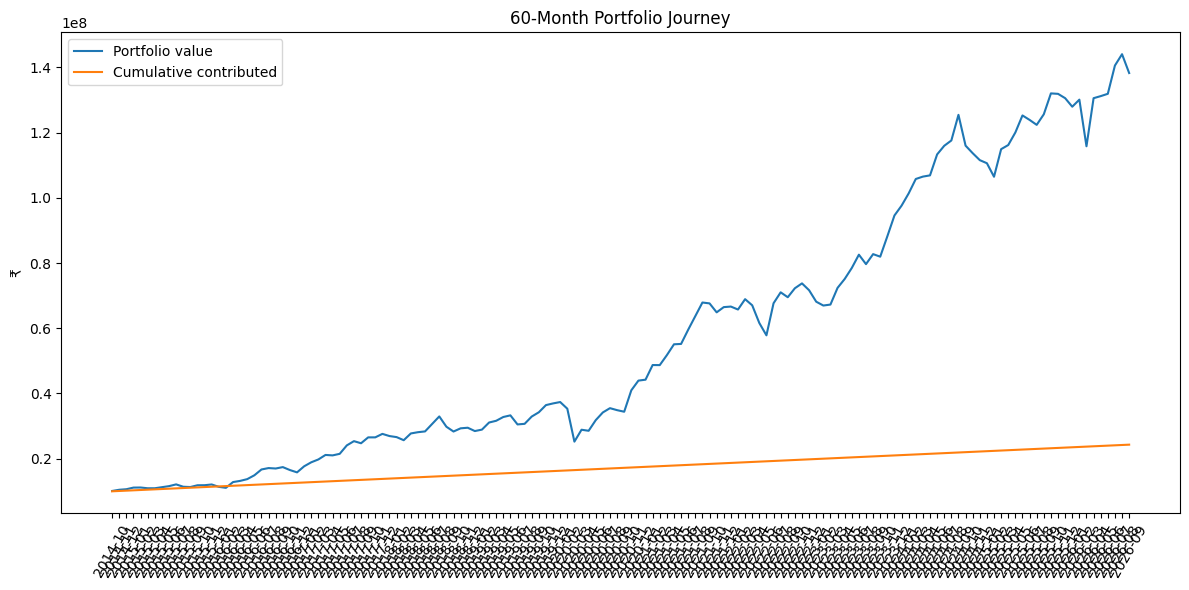

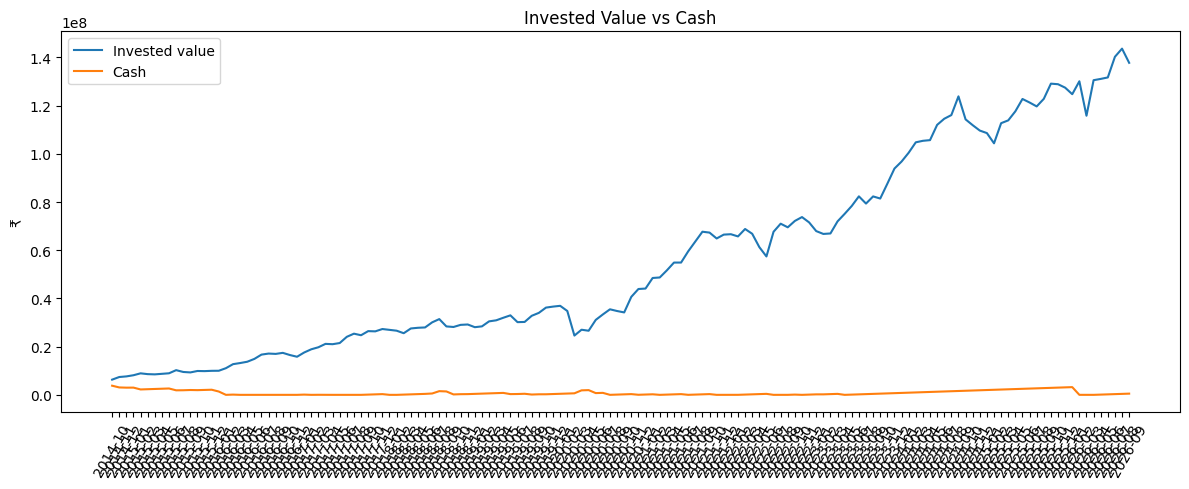

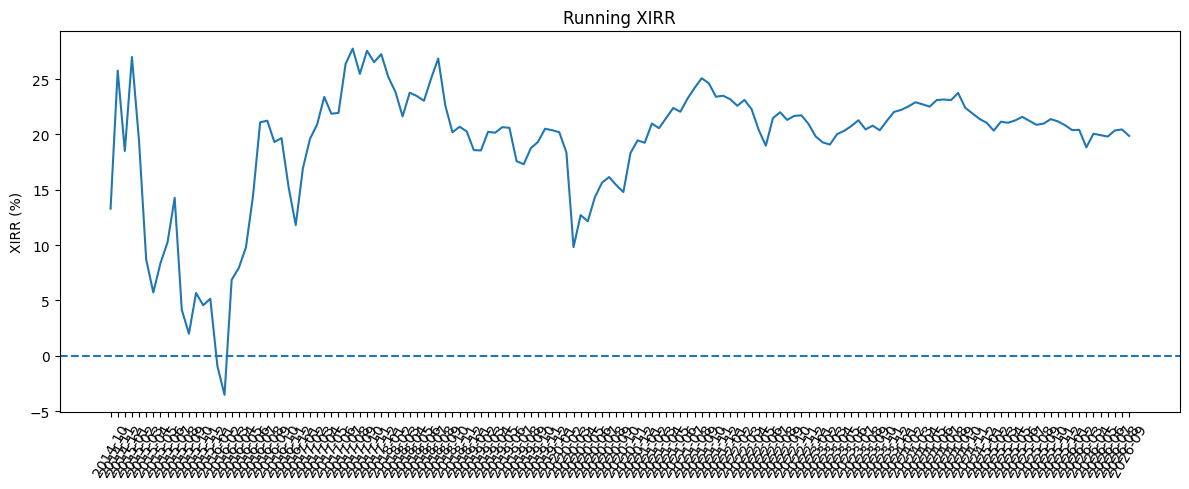

In [28]:
# 32. Portfolio journey charts

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_journey["month"], monthly_journey["portfolio_value"], label="Portfolio value")
ax.plot(monthly_journey["month"], monthly_journey["cumulative_contributed"], label="Cumulative contributed")
ax.set_title("60-Month Portfolio Journey")
ax.set_ylabel("₹")
ax.tick_params(axis="x", rotation=60)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_journey["month"], monthly_journey["gross_invested_value"], label="Invested value")
ax.plot(monthly_journey["month"], monthly_journey["cash_left"], label="Cash")
ax.set_title("Invested Value vs Cash")
ax.set_ylabel("₹")
ax.tick_params(axis="x", rotation=60)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_journey["month"], monthly_journey["xirr"] * 100)
ax.axhline(0, linestyle="--")
ax.set_title("Running XIRR")
ax.set_ylabel("XIRR (%)")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()


## 27. Final journey summary

In [29]:
# 33. Final journey summary

last = monthly_journey.iloc[-1]
print("FINAL JOURNEY SUMMARY")
print("=" * 60)
print(f"Journey: {START_DATE} → {END_DATE} ({n_months} months)")
print(f"Initial lump sum: {format_inr(INITIAL_LUMP_SUM)}")
print(f"Monthly SIP: {format_inr(MONTHLY_SIP)}")
print(f"Total contributed: {format_inr(last['cumulative_contributed'])}")
print(f"Cumulative deployed into purchases: {format_inr(last['cumulative_deployed'])}")
print(f"Cumulative trim proceeds: {format_inr(last['cumulative_trim_proceeds'])}")
print(f"Final invested value: {format_inr(last['gross_invested_value'])}")
print(f"Final cash: {format_inr(last['cash_left'])}")
print(f"Final portfolio value: {format_inr(last['portfolio_value'])}")
print(f"Absolute profit: {format_inr(last['absolute_profit'])}")
print(f"Absolute profit %: {last['absolute_profit_pct']:.2%}")
print(f"XIRR: {last['xirr']:.2%}")
print(f"Final invested %: {last['invested_pct']:.2%}")
print(f"Final holdings: {int(last['num_holdings'])}")
print(f"Max final sector weight: {last['max_sector_weight']:.2%}")
print(f"Max sector at final month: {last['max_sector']}")
print(f"Sector cap: {MAX_SECTOR_PCT:.2%}")
print(f"Stock purchase cap: {MAX_POSITION_PCT:.2%}")
print(f"Position review threshold: {POSITION_REVIEW_PCT:.2%}")
print(f"Position hard threshold: {POSITION_HARD_PCT:.2%}")
print(f"Position trim target: {POSITION_TRIM_TARGET_PCT:.2%}")
print(f"Total buy events: {sum(trades['action'].eq('BUY')) if not trades.empty else 0:,}")
print(f"Total trim events: {sum(trades['action'].eq('TRIM')) if not trades.empty else 0:,}")
print(f"Data fingerprint: {DATA_FINGERPRINT}")
print("Integer-share trading: PASS")


FINAL JOURNEY SUMMARY
Journey: 2014-10-01 → 2026-09-30 (144 months)
Initial lump sum: ₹1,00,00,000
Monthly SIP: ₹1,00,000
Total contributed: ₹2,43,00,000
Cumulative deployed into purchases: ₹2,88,71,941
Cumulative trim proceeds: ₹50,72,439
Final invested value: ₹13,77,46,085
Final cash: ₹5,00,497
Final portfolio value: ₹13,82,46,583
Absolute profit: ₹11,39,46,583
Absolute profit %: 468.92%
XIRR: 19.87%
Final invested %: 99.64%
Final holdings: 15
Max final sector weight: 20.20%
Max sector at final month: FINANCE
Sector cap: 20.00%
Stock purchase cap: 7.00%
Position review threshold: 12.00%
Position hard threshold: 15.00%
Position trim target: 12.00%
Total buy events: 95
Total trim events: 5
Data fingerprint: 181f9c44d3cdd4d5
Integer-share trading: PASS


## 28. Export all outputs

In [30]:
# 34. Export the journey tables

stamp = f"{pd.Timestamp(START_DATE):%Y%m%d}_{pd.Timestamp(END_DATE):%Y%m%d}"
monthly_file = Path(f"ATH_Recovery_Journey_Monthly_{stamp}.csv")
trade_file = Path(f"ATH_Recovery_Journey_Trades_{stamp}.csv")
opp_file = Path(f"ATH_Recovery_Journey_Opportunities_{stamp}.csv")
hold_file = Path(f"ATH_Recovery_Journey_Holdings_{stamp}.csv")

monthly_journey.to_csv(monthly_file, index=False)
trades.to_csv(trade_file, index=False)
opportunities.to_csv(opp_file, index=False)
monthly_holdings.to_csv(hold_file, index=False)

print("Exported:")
for f in [monthly_file, trade_file, opp_file, hold_file]:
    print(f" - {f.resolve()}")


Exported:
 - /content/ATH_Recovery_Journey_Monthly_20141001_20260930.csv
 - /content/ATH_Recovery_Journey_Trades_20141001_20260930.csv
 - /content/ATH_Recovery_Journey_Opportunities_20141001_20260930.csv
 - /content/ATH_Recovery_Journey_Holdings_20141001_20260930.csv


In [31]:
# 41. Export enhanced outputs

snapshot_file = Path(f"ATH_Recovery_Journey_Holdings_Snapshot_{stamp}.csv")
compact_file = Path(f"ATH_Recovery_Journey_Monthly_Compact_{stamp}.csv")
sector_file = Path(f"ATH_Recovery_Journey_Sector_Snapshot_{stamp}.csv")
monthly_holdings_snapshot.to_csv(snapshot_file,index=False)
compact_monthly_snapshot.to_csv(compact_file,index=False)
sector_snapshot.to_csv(sector_file,index=False)
print("Additional exports:")
for f in [snapshot_file,compact_file,sector_file]: print(f" - {f.resolve()}")


Additional exports:
 - /content/ATH_Recovery_Journey_Holdings_Snapshot_20141001_20260930.csv
 - /content/ATH_Recovery_Journey_Monthly_Compact_20141001_20260930.csv
 - /content/ATH_Recovery_Journey_Sector_Snapshot_20141001_20260930.csv
